# 0. Instaliranje neophodnih biblioteka

In [4]:
%pip install pandas
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -------------------------------- ------- 6.6/8.0 MB 38.3 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 29.6 MB/s  0:00:00
   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   -------- ------------------------------- 8.1/36.5 MB 43.2 MB/s eta 0:00:01
   ------------------ --------------------- 17.3/36.5 MB 41.2 MB/s eta 0:00:01
   --------------------------- ------------ 24.9/36.5 MB 39.2 MB/s eta 0:00:01
   ----------------------------------- ---- 32.5/36.5 MB 38.2 MB/s eta 0:00:01
   ---------------------------------------- 36.5/36.5 MB 36.3 MB/s  0:00:01

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ------------------------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 1. Opis podataka za analiticki deo

- Koriscene tabele: races, results, circuits.
- Tabela sa objedinjenim podacima - svaki red jedan vozac, jedna trka
- Instanca: vozač u trci (analitički deo) / vozač u sezoni (prediktivni deo).
- Bitne kolone u results: 
- grid - startana pozicija na trci 
- position - finalni plasman u trci po zavrsetku trke
- year
- driverId
- raceId
- circuitId

# 2. Čišćenje podataka

- Filtrirani su podaci tako da obuhvataju samo trke iz perioda 2000–2024.
- Izvršena je konverzija kolona position i grid u numerički tip, pri čemu su vrednosti \N pretvorene u nedostajuće vrednosti (NaN).
- Uklonjeni su vozači bez numeričke finalne pozicije, odnosno zapisi koji predstavljaju DNF.
- Iz analize su izbačeni redovi sa nevalidnom startnom pozicijom (grid ≤ 0) kako bi ostali samo regularni startovi.
- Spojene su tabele sa rezultatima, trkama i stazama radi objedinjavanja informacija o godini i nazivu staze.
- Preimenovane su kolone radi jasnije interpretacije (start_position, finish_position, circuit_name).
- Izračunata je nova promenljiva position_change koja predstavlja razliku između startne i finalne pozicije.
- Dodata je kategorija drs_period kojom su podaci podeljeni na period pre (do 2010) i posle uvođenja DRS-a (2011–2024).


In [14]:
import pandas as pd

# === LOAD DATA ===
results = pd.read_csv("podaci/results.csv")
races = pd.read_csv("podaci/races.csv")
circuits = pd.read_csv("podaci/circuits.csv")

results["position"] = pd.to_numeric(results["position"], errors="coerce")
results["grid"] = pd.to_numeric(results["grid"], errors="coerce")

# === FILTER YEARS 2000-2024 ===
races_filtered = races[(races["year"] >= 2000) & (races["year"] <= 2024)]

# === ONLY FINISHED DRIVERS ===
# position -> exists not /N
# we want to keep only drivers who have numerical value in position -> means they finished race
results_finished = results[results["position"].notna()]

# === MERGE RESULTS + RACES ===
df = results_finished.merge(
    races_filtered[["raceId", "year", "circuitId"]],
    on="raceId",
    how="inner"
)

# === ADD CIRCUIT NAME ===
df = df.merge(
    circuits[["circuitId", "name"]],
    on="circuitId",
    how="left"
)

# === SELECT ONLY IMPORTANT COLUMNS ===
results_clean = df[[
    "raceId",
    "year",
    "circuitId",
    "name",
    "driverId",
    "grid",
    "position"
]]

# === RENAME COLUMNS ===
results_clean = results_clean.rename(columns={
    "name": "circuit_name",
    "grid": "start_position",
    "position": "finish_position"
})

# === REMOVE INVALID START POSITIONS ===
# grid = 0 or NaN means pit lane or unknown start
# keep only real grid slots
results_clean = results_clean[
    (results_clean["start_position"].notna()) &
    (results_clean["start_position"] >= 1)
]

results_clean = results_clean.reset_index(drop=True)

results_clean.head()

,raceId,year,circuitId,circuit_name,driverId,start_position,finish_position
0,18,2008,1,Albert Park Grand Prix Circuit,1,1,1.0
1,18,2008,1,Albert Park Grand Prix Circuit,2,5,2.0
2,18,2008,1,Albert Park Grand Prix Circuit,3,7,3.0
3,18,2008,1,Albert Park Grand Prix Circuit,4,11,4.0
4,18,2008,1,Albert Park Grand Prix Circuit,5,3,5.0


# 3. Kreiranje novih atributa (Feature engineering)

- Formirana je nova, očišćena tabela results_clean, koja predstavlja objedinjeni skup podataka spreman za analizu i dalje modelovanje. Tabela je eksportovana i kao poseban CSV fajl radi lakšeg korišćenja u nastavku projekta.
- Kreirana je nova kolona change_position, koja predstavlja meru napretka ili pada vozača u odnosu na startnu poziciju. Vrednost se računa formulom change_position = grid – position, čime se dobija informacija da li je vozač napredovao ili izgubio mesta tokom trke.


In [15]:

# === CALCULATE POSITION CHANGE ===
results_clean["position_change"] = results_clean["start_position"] - results_clean["finish_position"]

# === DRS PERIOD COLUMN ===
results_clean["drs_period"] = results_clean["year"].apply(
    lambda y: "pre_drs" if y <= 2010 else "post_drs"
)

# === SORT FOR CLEANER DATASET ===
results_clean = results_clean.sort_values(["year", "raceId", "finish_position"]).reset_index(drop=True)

print(results_clean.head())
print("Ukupno redova:", len(results_clean))


   raceId  year  circuitId                    circuit_name  driverId  \
0     158  2000          1  Albert Park Grand Prix Circuit        30   
1     158  2000          1  Albert Park Grand Prix Circuit        22   
2     158  2000          1  Albert Park Grand Prix Circuit        23   
3     158  2000          1  Albert Park Grand Prix Circuit        35   
4     158  2000          1  Albert Park Grand Prix Circuit        21   

   start_position  finish_position  position_change drs_period  
0               3              1.0              2.0    pre_drs  
1               4              2.0              2.0    pre_drs  
2              11              3.0              8.0    pre_drs  
3               8              4.0              4.0    pre_drs  
4               9              5.0              4.0    pre_drs  
Ukupno redova: 7878


# 4. Eksplorativna analiza (EDA)

### Grafikon 1 — Globalna korelacija (odnos) startne i finalne pozicije
Grafikon prikazuje odnos izmedju startne pozicije vozaca i njegovog konacnog plasmana u trci sa ciljem utvrdjivanja da li startna pozicija predstavlja znacajan faktor rezultata. Na x-osi prikazana je startna pozicija (grid), dok y-osa predstavlja konacnu poziciju u trci. Svaka tacka odgovara jednom nastupu vozaca u jednoj trci. Regresiona prava prikazuje prosecnu linearnu vezu izmedju startne i finalne pozicije i omogucava procenu da li promena startne pozicije dovodi do proporcionalne promene konacnog plasmana.
#### Zaključak
Uocava se pozitivna linearna veza izmedju startne i finalne pozicije, sto ukazuje da vozaci koji startuju sa boljih pozicija u proseku ostvaruju bolje rezultate. Istovremeno, prisutno rasipanje tacaka oko regresione linije pokazuje da startna pozicija ne objasnjava u potpunosti konacni ishod trke, vec da na rezultat uticu i dodatni faktori.

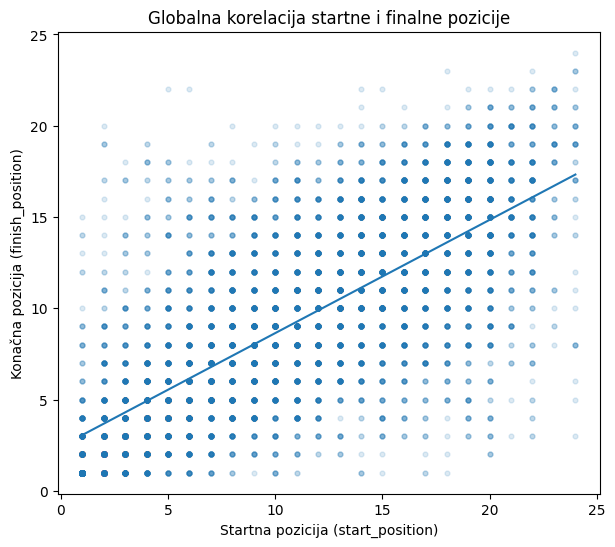

Broj uzoraka: 7878
Pearson korelacija: 0.7380479932755983


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# koriscena tabele results_clean
df = results_clean.dropna(subset=["start_position", "finish_position"]).copy()

# validan opseg
df = df[(df["start_position"] > 0) & (df["finish_position"] > 0)]

plt.figure(figsize=(7,6))
plt.scatter(df["start_position"], df["finish_position"], alpha=0.15, s=12)

# trend linija - regresiona linija
# Greska - vertikalna udaljenost tacke od linije
# Najbolja linija minimizira zbir kvadrata tih gresaka
# np.polyfit - vraca koeficijente pravca (m, b) za y = mx + b
m, b = np.polyfit(df["start_position"], df["finish_position"], 1)
x = np.array([df["start_position"].min(), df["start_position"].max()])
plt.plot(x, m*x + b)

plt.title("Globalna korelacija startne i finalne pozicije")
plt.xlabel("Startna pozicija (start_position)")
plt.ylabel("Konačna pozicija (finish_position)")
plt.show()

print(f"Broj uzoraka: {len(df)}")
# Pearsonov koeficijent korelacije meri linearnu zavisnost izmedju dve promenljive
# Vrednost blizu 1 ili -1 ukazuje na jaku pozitivnu ili negativnu korelaciju, dok vrednost blizu 0 ukazuje na slabiju korelaciju
print("Pearson korelacija:", df["start_position"].corr(df["finish_position"]))

### Grafikon 2 - Prosečna apsolutna promena pozicije po stazi
Grafikon prikazuje prosecnu apsolutnu promenu pozicije vozaca po stazama kako bi se uocilo na kojim stazama dolazi do vecih promena plasmana tokom trke. Promena pozicije racunata je kao apsolutna razlika izmedju startne i konacne pozicije (|start_position − finish_position|), cime se meri koliko se vozac pomerio tokom trke, bez obzira da li je napredovao ili izgubio pozicije. Analiza obuhvata deset najzastupljenijih staza sa najmanje 200 zabelezenih rezultata kako bi poredjenje bilo pouzdanije. Vece prosecne vrednosti ukazuju na dinamicnije trke sa vise promena pozicija, dok manje vrednosti ukazuju na stabilnije trke u kojima startna pozicija ima veci uticaj na konacan plasman.

#### Zakljucak
Staze sa vecom prosecnom apsolutnom promenom pozicije pokazuju vecu dinamiku trke, odnosno cesce promene plasmana tokom voznje. To ukazuje na veci broj preticanja i manju stabilnost konacnih rezultata, zbog cega startna pozicija na tim stazama ima slabiji uticaj na krajnji plasman. Sa druge strane, staze sa manjim prosecnim promenama pozicija karakterisu stabilnije trke, gde startna pozicija predstavlja pouzdaniji pokazatelj konacnog rezultata i osvajanja bodova. Razlike izmedju staza ukazuju na postojanje interakcije izmedju startne pozicije i karakteristika same staze, pri cemu se staze poput Gilles Villeneuve izdvajaju kao izrazito dinamicne.

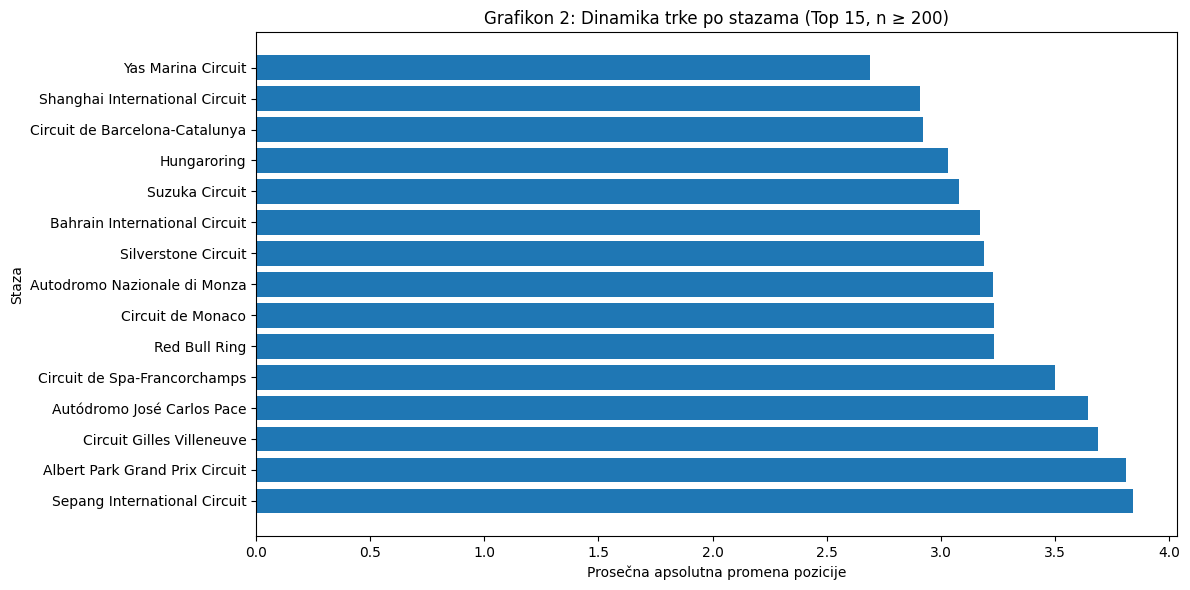

,circuit_name,n,avg_abs_change
31,Sepang International Circuit,287,3.843206
0,Albert Park Grand Prix Circuit,319,3.811912
10,Circuit Gilles Villeneuve,340,3.688235
6,Autódromo José Carlos Pace,385,3.644156
16,Circuit de Spa-Francorchamps,379,3.501319
30,Red Bull Ring,269,3.234201
14,Circuit de Monaco,364,3.230769
3,Autodromo Nazionale di Monza,425,3.228235
33,Silverstone Circuit,439,3.186788
7,Bahrain International Circuit,368,3.171196


In [70]:
df = results_clean.dropna(subset=[
    "circuit_name",
    "start_position",
    "finish_position"
]).copy()

df["abs_change"] = (df["start_position"] - df["finish_position"]).abs()

# grupisanje po stazi
# n je broj trkača koji su završili trku na toj stazi
n_per = df.groupby("circuit_name").size().rename("n")

# prosečna apsolutna promena
avg_abs_change = df.groupby("circuit_name")["abs_change"].mean()

circuit_stats = pd.concat([n_per, avg_abs_change], axis=1).reset_index()
circuit_stats.columns = ["circuit_name", "n", "avg_abs_change"]

MIN_N = 200
circuit_stats = circuit_stats[circuit_stats["n"] >= MIN_N]

# 10 zbog bolje preglednosti grafikona
TOP_K = 15
top = circuit_stats.sort_values("n", ascending=False).head(TOP_K)

# sortiraj po dinamici
top = top.sort_values("avg_abs_change", ascending=False)

plt.figure(figsize=(12, 6))
plt.barh(top["circuit_name"], top["avg_abs_change"])
plt.xlabel("Prosečna apsolutna promena pozicije")
plt.ylabel("Staza")
plt.title("Grafikon 2: Dinamika trke po stazama (Top 15, n ≥ 200)")
plt.tight_layout()
plt.show()

display(top)

### Grafikon 3 - Verovatnoća zadržavanja startne pozicije po stazama
Grafikon prikazuje verovatnocu da vozac zavrsi trku na istoj poziciji sa koje je startovao (finish_position = start_position) za razlicite staze. Ova mera predstavlja stabilnost poretka (redosleda vozaca) tokom trke, odnosno ucestalost situacija u kojima ne dolazi do promene plasmana. Veca verovatnoca ukazuje na stabilnije trke u kojima startna pozicija ima veci znacaj, dok manja verovatnoca ukazuje na veci broj promena pozicija i dinamicniji tok trke sa vise preticanja.

#### Zakljucak
Verovatnoca zadrzavanja startne pozicije varira izmedju staza, ali je u svim slucajevima relativno niska i ostaje ispod 25%, sto pokazuje da se poredak tokom trke cesto menja. Na dinamicnijim stazama dolazi do veceg broja promena plasmana, pa startna pozicija nije jedini odlucujuci faktor konacnog rezultata. Rezultati ukazuju da uticaj startne pozicije zavisi od karakteristika same staze. Ovaj grafikon meri potpunu stabilnost poretka, dok prethodni grafikon prikazuje intenzitet promena pozicija tokom trke.

##### Napomena: Ovaj grafikon analizira potpunu STABILNOST poretka, dok prethodni jacinu veze i intenzitet promena. 


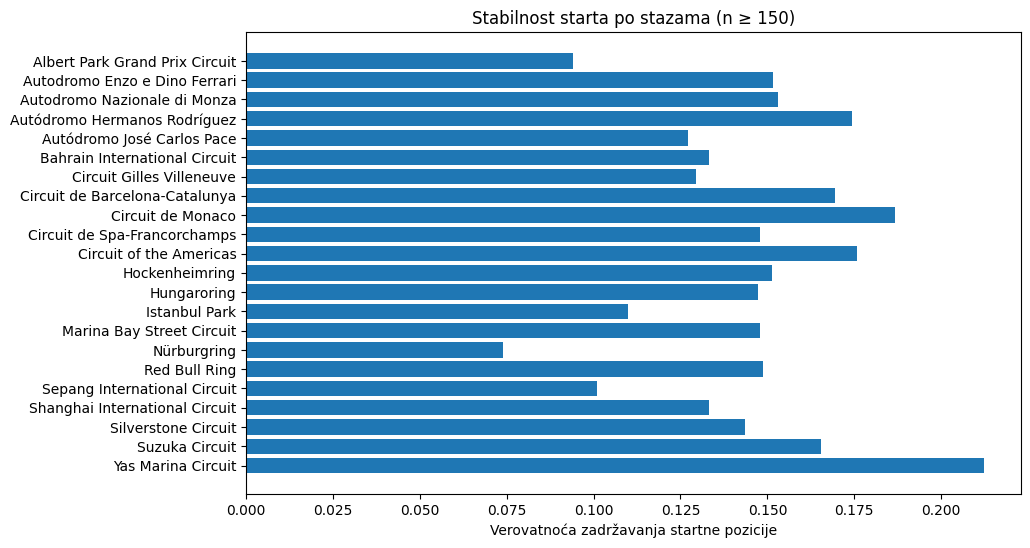

In [77]:
df = results_clean.dropna(subset=[
    "circuit_name",
    "start_position",
    "finish_position"
]).copy()

df["same_position"] = df["start_position"] == df["finish_position"]

prob_same = df.groupby("circuit_name")["same_position"].mean().reset_index()

# uzmi top 10 po broju uzoraka
counts = df.groupby("circuit_name").size().reset_index(name="n")
prob_same = prob_same.merge(counts, on="circuit_name")
prob_same = prob_same[prob_same["n"] >= 150]

plt.figure(figsize=(10,6))
plt.barh(prob_same["circuit_name"], prob_same["same_position"])
plt.xlabel("Verovatnoća zadržavanja startne pozicije")
plt.title("Stabilnost starta po stazama (n ≥ 150)")
plt.gca().invert_yaxis()
plt.show()

### Grafikon 4 - Verovatnoca velikog pada sa vrha grida (P1-P5)
Grafikon prikazuje verovatnocu da vozac koji startuje sa vodecih pozicija (P1–P5) dozivi znacajan pad tokom trke. Veliki pad definisan je kao gubitak najmanje pet pozicija u odnosu na startnu poziciju. Analiza ispituje koliko je vrh grida stabilan, odnosno koliki je rizik da vozaci koji startuju medju prvih pet izgube znacajan broj pozicija tokom trke.

#### Zakljucak 
Verovatnoca velikog pada za vozace koji startuju u vrhu grida je relativno mala i iznosi oko 10%, sto pokazuje da vodece startne pozicije u vecini slucajeva predstavljaju stabilnu prednost. Rezultati ukazuju da start iz prvih pet pozicija retko dovodi do znacajnog gubitka plasmana tokom trke.

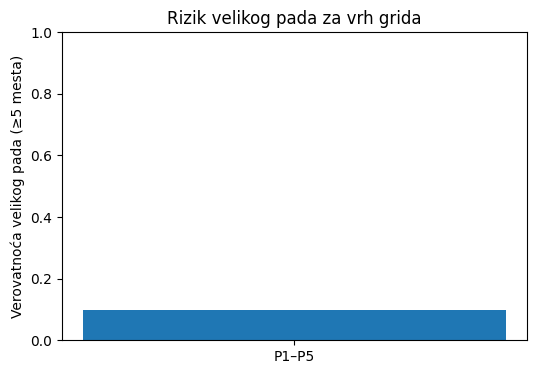

Verovatnoća velikog pada za P1–P5: 0.09937288953207911


In [86]:
df = results_clean.dropna(subset=["start_position","finish_position"]).copy()

df["position_change"] = df["start_position"] - df["finish_position"]

# samo vrh grida
# uzemo samo vozace(ucesnike) koji su startovali sa pozicija 1-5
top5 = df[df["start_position"] <= 5].copy()

# veliki pad (izgubio 5 ili više mesta)
top5["big_drop"] = top5["position_change"] <= -5

#racunanje verovatnoće velikog pada
prob_drop = top5["big_drop"].mean()

plt.figure(figsize=(6,4))
plt.bar(["P1–P5"], [prob_drop])
plt.ylabel("Verovatnoća velikog pada (≥5 mesta)")
plt.title("Rizik velikog pada za vrh grida")
plt.ylim(0, 1)
plt.show()

print("Verovatnoća velikog pada za P1–P5:", prob_drop)

### Grafikon 5 - Verovatnoca velikog napredovanja zadnjih startnih pozicija (P15-P20)
Grafikon prikazuje verovatnocu da vozac koji startuje sa zadnjih startnih pozicija (P15–P20) napreduje najmanje pet mesta tokom trke. Veliko napredovanje definisano je kao poboljsanje plasmana za pet ili vise pozicija u odnosu na start. Racuna se udeo takvih slucajeva medju svim vozacima koji su zapoceli trku iz ove grupe, kako bi se procenilo u kojoj meri startna pozicija ogranicava mogucnost znacajnog napredovanja tokom trke.

#### Zakljucak
Rezultati pokazuju da vozaci koji startuju sa zadnjih startnih pozicija gridaimaju veoma veliku sansu da tokom trke poprave svoj plasman. Startna pozicija u ovom delu startnog rasporeda ne predstavlja cvrsto ogranicenje konacnog rezultata, sto ukazuje na vecu dinamiku i cesce promene pozicija tokom trke.

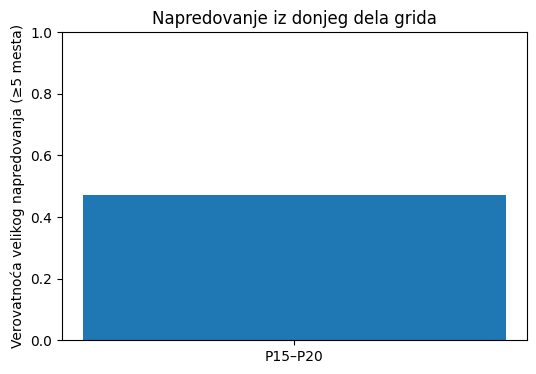

Verovatnoća velikog napredovanja za P15–P20: 0.4704412989175687


In [89]:
df = results_clean.dropna(subset=["start_position","finish_position"]).copy()

df["position_change"] = df["start_position"] - df["finish_position"]

# donji deo grida (P15–P20)
bottom_group = df[df["start_position"] >= 15].copy()

bottom_group["big_gain"] = bottom_group["position_change"] >= 5

prob_gain = bottom_group["big_gain"].mean()

plt.figure(figsize=(6,4))
plt.bar(["P15–P20"], [prob_gain])
plt.ylabel("Verovatnoća velikog napredovanja (≥5 mesta)")
plt.title("Napredovanje iz donjeg dela grida")
plt.ylim(0, 1)
plt.show()

print("Verovatnoća velikog napredovanja za P15–P20:", prob_gain)

### Grafikon 6 - Verovatnoća velikog napredovanja (>= 5 mesta) po segmentima grida grupisano po stazama 
Grafikon prikazuje verovatnocu velikog napredovanja (najmanje pet osvojenih pozicija tokom trke) za razlicite startne segmente grida (P1–P5, P6–P10, P11–P15 i P16–P20) na svakoj od analiziranih staza. Analiza omogucava poredjenje koliko vozaci iz razlicitih delova startnog rasporeda mogu da poprave svoj plasman, a takodje i ispitivanje interakcije izmedju startne pozicije i karakteristika staze.

#### Zakljucak 
Vozaci koji startuju iz segmenta P1–P5 gotovo nikada ne ostvaruju veliko napredovanje, sto je ocekivano jer vec zapocinju trku na vodecim pozicijama. Najvecu verovatnocu znacajnog napretka imaju vozaci iz segmenta P16–P20, koji poseduju najveci prostor za pomeranje kroz poredak. Uocava se da se intenzitet ovog efekta razlikuje medju stazama, pri cemu na pojedinim stazama vozaci iz zadnjih startnih segmenata imaju znatno vecu sansu za napredovanje nego na drugim. Rezultati ukazuju da uticaj startne pozicije nije jednak duz celog grida, vec zavisi i od karakteristika same staze.

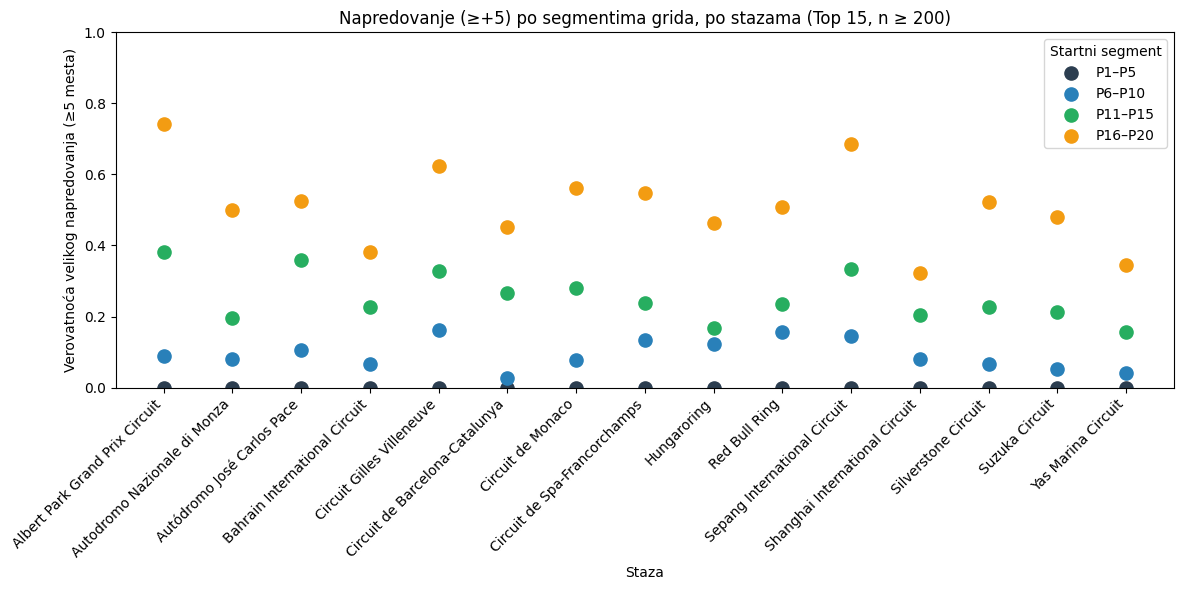

In [107]:
df = results_clean.dropna(subset=["start_position", "finish_position", "circuit_name"]).copy()
# promena pozicije: pozitivno = napredovao
df["position_change"] = df["start_position"] - df["finish_position"]

# segmentacija grida
def segment_grid(pos):
    if pos <= 5:
        return "P1–P5"
    elif pos <= 10:
        return "P6–P10"
    elif pos <= 15:
        return "P11–P15"
    else:
        return "P16–P20"

order = ["P1–P5", "P6–P10", "P11–P15", "P16–P20"]
colors = ["#2c3e50", "#2980b9", "#27ae60", "#f39c12"]

df["grid_segment"] = df["start_position"].apply(segment_grid)

# veliki napredak (>= +5 pozicija)
df["big_gain"] = df["position_change"] >= 5
MIN_N = 200  
TOP_CIRCUITS = 15 
counts = df.groupby("circuit_name").size().reset_index(name="n")
counts = counts[counts["n"] >= MIN_N].sort_values("n", ascending=False)

top_circuits = counts.head(TOP_CIRCUITS)["circuit_name"].tolist()
df_top = df[df["circuit_name"].isin(top_circuits)].copy()

# --- verovatnoće po (staza, segment) ---
stats = (df_top.groupby(["circuit_name", "grid_segment"])["big_gain"].mean().reset_index())

# obezbedi redosled segmenata
stats["grid_segment"] = pd.Categorical(stats["grid_segment"], categories=order, ordered=True)
stats = stats.sort_values(["circuit_name", "grid_segment"])

plt.figure(figsize=(12, 6))
for seg, col in zip(order, colors):
    tmp = stats[stats["grid_segment"] == seg]
    plt.scatter(tmp["circuit_name"], tmp["big_gain"], s=90, label=seg, color=col)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Verovatnoća velikog napredovanja (≥5 mesta)")
plt.xlabel("Staza")
plt.title(f"Napredovanje (≥+5) po segmentima grida, po stazama (Top {TOP_CIRCUITS}, n ≥ {MIN_N})")
plt.ylim(0, 1)
plt.legend(title="Startni segment")
plt.tight_layout()
plt.show()

#display(stats)

### Grafikon 7 - Distribucija apsolutne promene pozicije (|Δposition|) pre vs posle DRS
Grafikon prikazuje distribuciju apsolutne promene pozicije vozaca (|Δposition|), odnosno koliko se vozac pomerio u odnosu na startnu poziciju, pre i posle uvodjenja DRS sistema. Analiza ima za cilj da ispita da li je struktura promena pozicija tokom trka postala drugacija nakon 2011. godine, kada je DRS uveden u Formulu 1. Na x-osi prikazana je apsolutna promena pozicije, koja predstavlja broj osvojenih ili izgubljenih mesta tokom trke, dok y-osa pokazuje koliko cesto se odredjena promena desava. Na ovaj nacin moguce je uporediti dinamiku trka u periodu pre i posle uvodjenja DRS-a.

#### Zakljucak 
Sa grafikona se vidi da vrednost 0 oznacava situacije u kojima vozac nije promenio poziciju, dok vrednosti od 1 do 3 predstavljaju manje promene plasmana. Vece vrednosti ukazuju na znacajnije promene pozicija tokom trke. Nakon uvodjenja DRS sistema primecuje se veca zastupljenost srednjih i vecih promena pozicija, sto ukazuje na povecanu dinamiku trka. Rezultati sugerisu da je DRS doprineo vecim mogucnostima preticanja i smanjenju stabilnosti pocetnog redosleda vozaca.


#### Opis DRS sistem
DRS (Drag Reduction System) je sistem uveden 2011. godine u Formuli 1 koji omogucava vozacu privremeno smanjenje aerodinamickog otpora otvaranjem zadnjeg krila, cime se povecava brzina na pravcima. Osnovni cilj sistema je olaksavanje preticanja i povecanje dinamike trke.

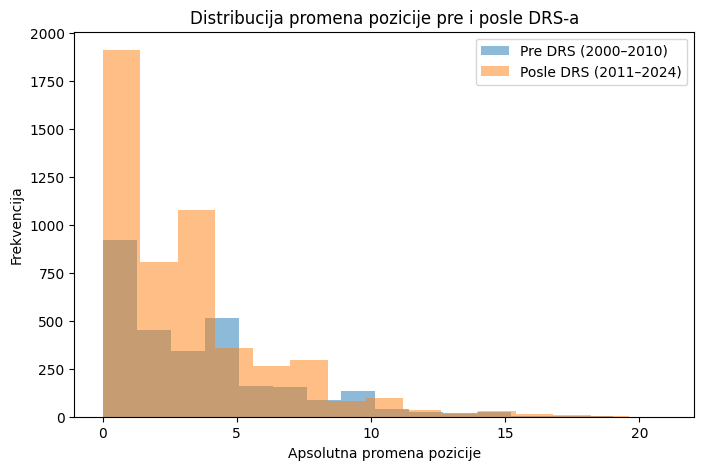

In [122]:
df = results_clean.dropna(subset=["start_position","finish_position","year"]).copy()

df["abs_change"] = (df["start_position"] - df["finish_position"]).abs()

# period
df["period"] = df["year"].apply(lambda y: "Pre DRS (2000–2010)" if y <= 2010 else "Posle DRS (2011–2024)")

plt.figure(figsize=(8,5))

for period, color in zip(
    ["Pre DRS (2000–2010)", "Posle DRS (2011–2024)"],
    ["#0553a0", "#e74c3c"]
):
    subset = df[df["period"] == period]
    plt.hist(subset["abs_change"], bins=15, alpha=0.5, label=period)

plt.xlabel("Apsolutna promena pozicije")
plt.ylabel("Frekvencija")
plt.title("Distribucija promena pozicije pre i posle DRS-a")
plt.legend()
plt.show()

### Grafikon 8 - Grafikon prikazuje poređenje promene pozicije vozača tokom trke pre i posle uvođenja DRS sistema (boxplot)
Grafikon prikazuje poredjenje promene pozicije vozaca tokom trke pre i posle uvodjenja DRS sistema koristeci boxplot prikaz. Promena pozicije definisana je kao razlika start_position − finish_position, gde pozitivne vrednosti oznacavaju napredovanje vozaca, negativne nazadovanje, dok vrednosti blizu nule ukazuju na zadrzavanje slicnog plasmana. Boxplot omogucava uvid u tipicnu vrednost promene (medijanu), rasipanje rezultata, kao i prisustvo ekstremnih slucajeva u oba posmatrana perioda.

#### Zakljucak 
Nakon uvodjenja DRS sistema primecuje se veci raspon promena pozicija i veci broj ekstremnih vrednosti u odnosu na period pre DRS-a. Ovakav obrazac ukazuje na povecanu dinamiku trka i cesca znacajna pomeranja plasmana tokom voznje, sto je u skladu sa ciljem DRS sistema da olaksa preticanje.

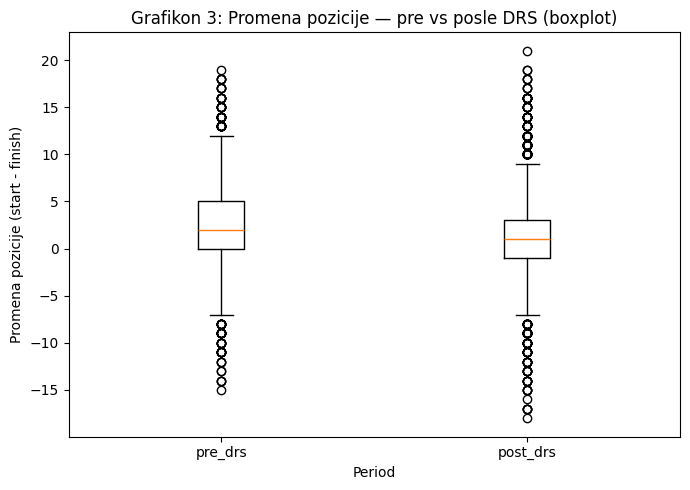

In [125]:
df_drs = results_clean.dropna(subset=["drs_period", "position_change"]).copy()

# Obezbedi stabilan redosled
order = [p for p in ["pre_drs", "post_drs"] if p in df_drs["drs_period"].unique()]
data = [df_drs.loc[df_drs["drs_period"] == p, "position_change"].values for p in order]

plt.figure(figsize=(7, 5))
plt.boxplot(data, tick_labels=order) 
plt.xlabel("Period")
plt.ylabel("Promena pozicije (start - finish)")
plt.title("Grafikon 3: Promena pozicije — pre vs posle DRS (boxplot)")
plt.tight_layout()
plt.show()

### Grafikon 9 - Udeo malih (1-3 mesta) i velikih napredovanja (>= 5 mesta) pre i posle DRS-a

Grafikon prikazuje poredjenje ucestalosti malih i velikih napredovanja u trkama pre i posle uvodjenja DRS sistema. Veliko napredovanje definisano je kao pomeranje za najmanje pet pozicija (start_position − finish_position >= 5), dok mala napredovanja obuhvataju promene od jedne do tri pozicije. Posmatranje intervala 1–3 je korisno zato sto prethodni grafikoni pokazuju da se najveci deo promena tokom trke upravo nalazi u zoni manjih pomeranja, pa ovde izdvajamo “tipicna” preticanja od ekstremnih skokova u plasmanu.

#### Zakljucak 
Rezultati pokazuju da su mala napredovanja blago cesca u periodu posle 2011. godine, dok su velika napredovanja primetno redja u post-DRS eri. To znaci da nakon uvodjenja DRS-a trke imaju vise manjih promena pozicija, ali manje ekstremnih skokova u plasmanu. Ovakav obrazac sugerise da DRS pre svega olaksava ciljna i “kontrolisana” preticanja (najcesce 1–2 mesta), sto doprinosi dinamici trke, ali ne mora da dovede do velikih pomeranja od 7–10 pozicija.

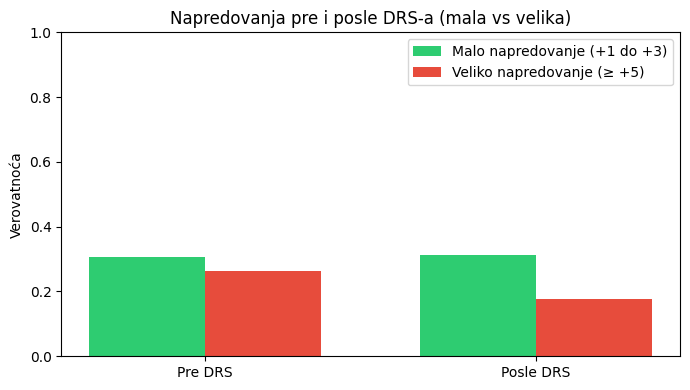

,period,small_gain,big_gain
1,Pre DRS,0.305402,0.263504
0,Posle DRS,0.312625,0.177154


In [ ]:
df = results_clean.dropna(subset=["start_position","finish_position","year"]).copy()

df["position_change"] = df["start_position"] - df["finish_position"]

# period
df["period"] = df["year"].apply(lambda y: "Pre DRS" if y <= 2010 else "Posle DRS")

# definicije napredovanja
df["small_gain"] = df["position_change"].between(1, 3)   # +1 do +3
df["big_gain"]   = df["position_change"] >= 5            # +5 ili više

# verovatnoće po periodu
stats = df.groupby("period")[["small_gain","big_gain"]].mean().reset_index()

# da redosled bude stabilan
order = ["Pre DRS", "Posle DRS"]
stats["period"] = pd.Categorical(stats["period"], categories=order, ordered=True)
stats = stats.sort_values("period")

# --- plot (grouped bar) ---
x = np.arange(len(stats["period"]))
w = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - w/2, stats["small_gain"], width=w, label="Malo napredovanje (+1 do +3)", color="#2ecc71")
plt.bar(x + w/2, stats["big_gain"],   width=w, label="Veliko napredovanje (≥ +5)",   color="#e74c3c")

plt.xticks(x, stats["period"])
plt.ylabel("Verovatnoća")
plt.title("Napredovanja pre i posle DRS-a (mala vs velika)")
plt.ylim(0,1)
plt.legend()
plt.tight_layout()
plt.show()

stats

#### Grafikon 10 - Prosečna korelacija start–finish po sezonama (trend kroz vreme)
Grafikon prikazuje kako se odnos izmedju startne i konacne pozicije menja kroz vreme, posmatrano po sezonama. Na x-osi prikazana je sezona, dok y-osa predstavlja Pearson korelaciju izmedju startne i finalne pozicije vozaca. Vrednosti blize 1 ukazuju da vozaci koji startuju napred uglavnom zavrsavaju trku na vodecim pozicijama, dok nize vrednosti ukazuju na veci broj promena plasmana tokom trke. Crvena isprekidana linija oznacava 2011. godinu, odnosno uvodjenje DRS sistema, kako bi se vizuelno procenilo da li je doslo do promene trenda nakon te regulatorne izmene.

#### Zakljucak 
Rezultati pokazuju prisustvo oscilacija izmedju sezona, ali bez izrazene promene dugorocnog trenda. Korelacija startne i finalne pozicije ostaje relativno visoka tokom celog posmatranog perioda, uglavnom u opsegu izmedju 0.7 i 0.8. Nakon 2011. godine ne uocava se nagli pad korelacije, sto ukazuje da uvodjenje DRS sistema nije znacajno smanjilo uticaj startne pozicije na konacan rezultat, vec je start i dalje ostao jedan od kljucnih faktora plasmana.

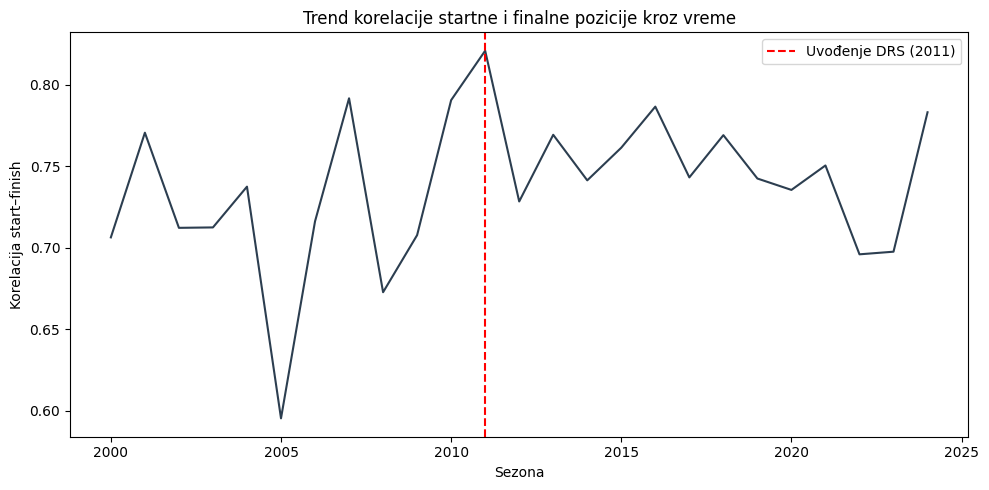

,year,correlation
0,2000,0.706338
1,2001,0.770470
2,2002,0.712190
3,2003,0.712448
4,2004,0.737426


In [132]:
df = results_clean.dropna(subset=["start_position","finish_position","year"]).copy()

# sigurnost: uveri se da su brojevi
df["start_position"] = pd.to_numeric(df["start_position"], errors="coerce")
df["finish_position"] = pd.to_numeric(df["finish_position"], errors="coerce")
df = df.dropna(subset=["start_position","finish_position","year"])

# korelacija po godinama (bez groupby.apply warning-a)
year_corr = (
    df.groupby("year")[["start_position", "finish_position"]]
      .corr()
      .iloc[0::2, -1]     # uzmi korelaciju start vs finish iz matrice
      .reset_index()
)

year_corr.columns = ["year", "level_1", "correlation"]
year_corr = year_corr[year_corr["level_1"] == "start_position"][["year","correlation"]]

plt.figure(figsize=(10,5))
plt.plot(year_corr["year"], year_corr["correlation"], color="#2c3e50")

plt.axvline(2011, color="red", linestyle="--", label="Uvođenje DRS (2011)")
plt.xlabel("Sezona")
plt.ylabel("Korelacija start–finish")
plt.title("Trend korelacije startne i finalne pozicije kroz vreme")
plt.legend()
plt.tight_layout()
plt.show()

display(year_corr.head())

# 5. Formiranje prediktivnog skupa

Instanca = vozač u sezoni
Ulaz = rezultati iz prvih 12 trka
Cilj = da li je šampion


In [21]:
import pandas as pd

# =========================================================
# LOAD DATA
# =========================================================
results = pd.read_csv("podaci/results.csv")
races = pd.read_csv("podaci/races.csv")
driver_standings = pd.read_csv("podaci/driver_standings.csv")

# =========================================================
# CONVERT NUMERIC COLUMNS
# =========================================================
results["positionOrder"] = pd.to_numeric(results["positionOrder"], errors="coerce")
results["grid"] = pd.to_numeric(results["grid"], errors="coerce")
results["points"] = pd.to_numeric(results["points"], errors="coerce")

# =========================================================
# MERGE RESULTS + RACES
# =========================================================
df = results.merge(
    races[["raceId", "year", "round"]],
    on="raceId",
    how="inner"
)

# FILTER YEARS 2000–2024
df = df[(df["year"] >= 2000) & (df["year"] <= 2024)]

# SORT
df = df.sort_values(["year", "driverId", "round"])

# =========================================================
# TAKE FIRST 12 RACES PER SEASON
# (ili manje ako sezona ima manje od 12)
# =========================================================
max_rounds_per_year = df.groupby("year")["round"].transform("max")
df["early_phase"] = df["round"] <= df.groupby("year")["round"].transform(
    lambda x: min(12, x.max())
)

first_part = df[df["early_phase"]]

# =========================================================
# FEATURE ENGINEERING (SEASON LEVEL)
# =========================================================
season_features = (
    first_part
    .groupby(["year", "driverId"])
    .agg(
        podiums_first12=("positionOrder", lambda x: (x <= 3).sum()),
        total_points_first12=("points", "sum"),
        avg_start_position=("grid", "mean"),
    )
    .reset_index()
)

# =========================================================
# DETERMINE CHAMPION CORRECTLY
# =========================================================

# Merge standings with race info
standings = driver_standings.merge(
    races[["raceId", "year", "round"]],
    on="raceId",
    how="left"
)

# Filter years
standings = standings[
    (standings["year"] >= 2000) &
    (standings["year"] <= 2024)
]

# Find final round per season
last_round_per_year = (
    standings.groupby("year")["round"]
    .max()
    .reset_index()
)

final_standings = standings.merge(
    last_round_per_year,
    on=["year", "round"],
    how="inner"
)

# Champion = position == 1
champions = final_standings[final_standings["position"] == 1][
    ["year", "driverId"]
]

champions["is_champion"] = 1

# =========================================================
# MERGE FEATURES + TARGET
# =========================================================
season_dataset = season_features.merge(
    champions,
    on=["year", "driverId"],
    how="left"
)

season_dataset["is_champion"] = (
    season_dataset["is_champion"]
    .fillna(0)
    .astype(int)
)

season_dataset = season_dataset.sort_values(
    ["year", "driverId"]
).reset_index(drop=True)

# =========================================================
# CHECK CLASS DISTRIBUTION
# =========================================================
print(season_dataset["is_champion"].value_counts())

season_dataset.head(60)

is_champion
0    542
1     25
Name: count, dtype: int64


,year,driverId,podiums_first12,total_points_first12,avg_start_position,is_champion
0,2000,2,0,0.0,17.454545,0
1,2000,14,9,58.0,2.333333,0
2,2000,15,0,6.0,7.583333,0
3,2000,18,0,8.0,13.250000,0
4,2000,21,3,18.0,9.583333,0
5,2000,22,7,49.0,4.833333,0
6,2000,23,1,16.0,8.916667,0
7,2000,25,0,0.0,13.750000,0
8,2000,30,7,62.0,2.166667,1
9,2000,35,0,11.0,9.500000,0


# 6. Primena jednog modela (baseline)

Izabrana metoda: Logistic Regression (jednostavan, interpretabilan, baseline)


In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Hronološki split
train = season_dataset[season_dataset["year"] <= 2018]
test = season_dataset[season_dataset["year"] > 2018]

features = ["podiums_first12", "total_points_first12", "avg_start_position"]

X_train = train[features]
y_train = train["is_champion"]

X_test = test[features]
y_test = test["is_champion"]

# Standardizacija
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression (uz balansiranje klase)
model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train_scaled, y_train)

# Predikcija
y_pred = model.predict(X_test_scaled)

# Evaluacija
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Koeficijenti
import pandas as pd
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

print("\nModel coefficients:")
print(coefficients)

Confusion Matrix:
[[102  16]
 [  0   6]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.86      0.93       118
           1       0.27      1.00      0.43         6

    accuracy                           0.87       124
   macro avg       0.64      0.93      0.68       124
weighted avg       0.96      0.87      0.90       124


Model coefficients:
                Feature  Coefficient
0       podiums_first12     1.321160
1  total_points_first12     0.388905
2    avg_start_position    -2.559543


# 7. Evaluacija

Koristim Precision, Recall, F1 score.
Ne koristim accuracy jer je dataset neuravnotežen (šampiona ima malo).


# 8. Zaključci

- Startna pozicija ima uticaj na finalni plasman, ali postoje značajna napredovanja i padovi.
- Rana forma (broj podijuma u prvih 12 trka) je dobar prediktor za šampiona.
- Dataset je neuravnotežen – evaluacija mora koristiti Precision, Recall, F1.
- Logistic Regression je dobar baseline, ali treba probati naprednije modele i dodatne analize.
